# Decision Tree

---
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davidrajm/DSA-DL-FDP/blob/main/Day%2002%20-%20Machine%20Learning%20-%20Dr%20Arun%20RajKumar/Lab%20Sessions/08_decision_tree.ipynb)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.tree                import DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
from sklearn.model_selection import train_test_split

from sklearn.datasets import make_classification
from sklearn.utils import Bunch

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid')

print("All libraries imported successfully.")

def compute_metrics(y_true, y_pred, label):
    """Return a dict of regression metrics for a given set of predictions."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Set': label, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}


All libraries imported successfully.


In [10]:
# Simulating the dataset.
X_raw, y = make_classification(
    n_samples=500,
    n_features=10,
    n_informative=7,
    n_redundant=2,
    n_classes=2,
    random_state=42
)

feature_names = [f'feature_{i}' for i in range(X_raw.shape[1])]
dataset = Bunch(
    data=X_raw,
    target=y,
    feature_names=feature_names,
    DESCR="Synthetic classification dataset via make_classification"
)

In [12]:
from sklearn.datasets import load_wine

dataset = load_wine()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

X = df.drop(columns='target')
y = df['target']                  # 0=Low, 1=Medium, 2=High

feature_names = dataset.feature_names

In [13]:
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['target'] = dataset.target

X = df.drop(columns='target')   # Feature matrix
y = df['target']                 # Labels: 0=Low, 1=Medium, 2=High

# ── 4. Train / Test Split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ── 5. Train Decision Tree ────────────────────────────────────────────────────
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print("Model trained on training set.")

Model trained on training set.


In [14]:
def plot_decision_tree_results(
    model,
    y_train, y_pred_train,
    y_test,  y_pred_test,
    feature_names,
    class_names=["Low", "Medium", "High"],
    figsize_main=(13, 4),
    figsize_tree=(20, 8),
):
    """
    Plots evaluation results for a trained Decision Tree Classifier.

    Parameters
    ----------
    model         : Trained DecisionTreeClassifier
    y_train       : True labels for training set
    y_pred_train  : Predicted labels for training set
    y_test        : True labels for test set
    y_pred_test   : Predicted labels for test set
    feature_names : List of feature names
    class_names   : List of class label strings       (default: Low/Medium/High)
    figsize_main  : Figure size for metrics + heatmap (default: (13, 4))
    figsize_tree  : Figure size for full tree diagram (default: (20, 8))
    """

    # ── 1. Metrics Table ──────────────────────────────────────────────────────
    results = pd.DataFrame([
        compute_metrics(y_train, y_pred_train, 'Train Set (80%)'),
        compute_metrics(y_test,  y_pred_test,  'Test Set  (20%)'),
    ]).set_index('Set').round(4)
    print(results.to_string())

    # ── 2. Confusion Matrix + Feature Importances ─────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=figsize_main)
    fig.suptitle("Decision Tree Classifier", fontsize=13, fontweight="bold")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[0]
    )
    axes[0].set_title("Confusion Matrix")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # Feature Importances
    importance_order = model.feature_importances_.argsort()
    axes[1].barh(
        [feature_names[i] for i in importance_order],
        model.feature_importances_[importance_order],
        color="#55A868", edgecolor="white"
    )
    axes[1].set_title("Feature Importances")
    axes[1].set_xlabel("Importance Score")

    plt.tight_layout()
    plt.show()

    # ── 3. Full Tree Diagram ──────────────────────────────────────────────────
    plt.figure(figsize=figsize_tree)
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=class_names,
        filled=True, rounded=True, fontsize=9
    )
    plt.title(
        f"Decision Tree — {' or '.join(class_names)}",
        fontsize=13, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()



                    MAE     MSE    RMSE      R2
Set                                            
Train Set (80%)  0.0000  0.0000  0.0000  1.0000
Test Set  (20%)  0.0833  0.1389  0.3727  0.7619


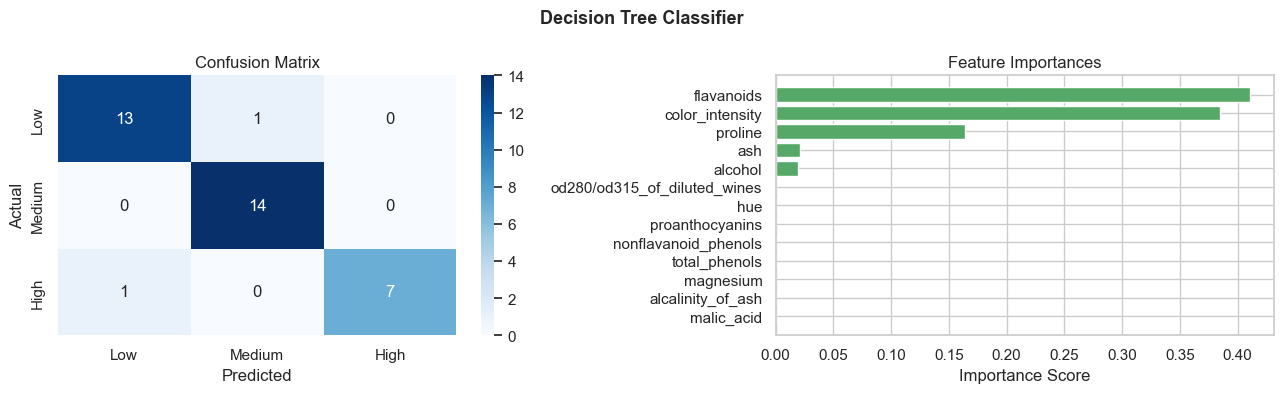

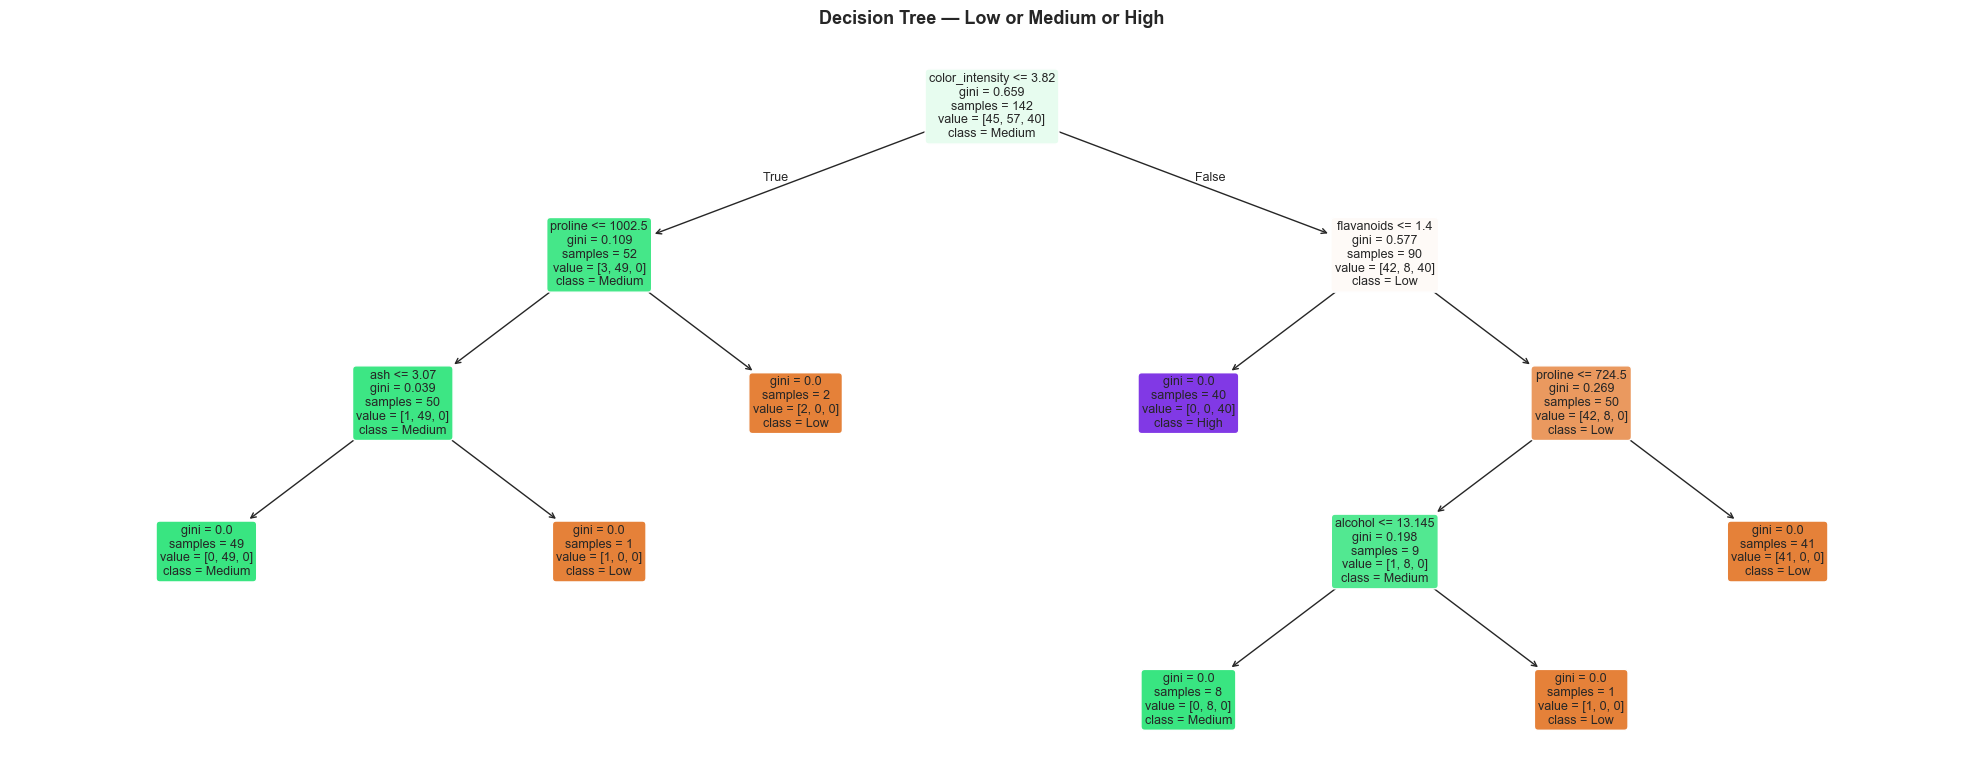

In [15]:
plot_decision_tree_results(
    model=model,
    y_train=y_train, y_pred_train=y_pred_train,
    y_test=y_test,   y_pred_test=y_pred_test,
    feature_names=feature_names,
)